# CLARA - Instacart (extended)


Evaluación del número de clusters y ajuste final del modelo. El `k` recomendado se selecciona mediante el mayor coeficiente silhouette.


In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

from modeling_functions import (
    clara_metrics,
    plot_clustering_metrics,
    analyze_clusters,
    fit_clustering_model,
    save_clustering_metrics,
)
import pandas as pd

## Carga y preparación de los datos


In [2]:
df_scaled = pd.read_csv("../../../scaled_data/instacart_scaled.csv")
df_original = pd.read_csv("../../../extended_datasets/instacart_model_extended.csv")

# Conserva en el escalado solo las variables incluidas en esta versión del dataset.
columnas_modelo = [col for col in df_original.columns if col in df_scaled.columns]
df_scaled_modelo = df_scaled[columnas_modelo].copy()
X = df_scaled_modelo.drop(columns=["user_id"], errors="ignore")

print(f"Observaciones: {X.shape[0]:,}")
print(f"Variables de clustering: {X.shape[1]}")
display(X.head())

Observaciones: 206,209
Variables de clustering: 11


,recency,frequency,avg_basket_size,std_basket_size,avg_days_between_orders,std_days_between_orders,unique_products,unique_aisles,unique_departments,reorder_ratio,product_variety_ratio
0,-0.286895,-0.070348,-0.578158,-1.227829,0.699419,0.241265,-0.990167,-1.002478,-1.009504,1.238152,-1.238152
1,1.212334,0.316791,0.820566,0.729024,0.322297,0.371165,0.903750,0.454433,0.572875,0.210583,-0.210583
2,-0.568000,0.138171,-0.236083,-0.814629,-0.427875,-1.032762,-0.338142,-0.660110,-0.482044,0.908586,-0.908586
3,1.212334,-0.826933,-1.313020,-0.833881,0.134288,0.741993,-1.050748,-0.825157,-0.482044,-1.775655,1.775655
4,-1.036509,-1.054508,0.139108,-0.260001,-0.769372,-0.728977,-0.728409,-0.660110,-0.482044,-0.253936,0.253936


## Evaluación del número de clusters


In [3]:
resultados_clara = clara_metrics(X)
display(resultados_clara)

,k,silhouette,calinski_harabasz,davies_bouldin,tiempo_segundos
0,2,0.272958,97741.540600,1.383058,0.141259
1,3,0.222483,74714.181384,1.449946,0.146595
2,4,0.165993,65518.392088,1.524517,0.146266
3,5,0.181068,54663.072555,1.638321,0.155380
4,6,0.156321,53264.767406,1.709712,0.162164
5,7,0.128732,45918.084218,1.833524,0.180830
6,8,0.122536,43402.020013,1.665010,0.191714
7,9,0.142852,39567.263136,1.526423,0.193329
8,10,0.126789,40811.146759,1.869886,0.198246


In [ ]:
tabla_metricas = save_clustering_metrics(
    resultados_clara,
    model_name="clara",
    dataset_name="instacart",
    dataset_version="extended",
)

print("Métricas consolidadas en ../../../results/clustering_metrics.csv")
display(tabla_metricas)

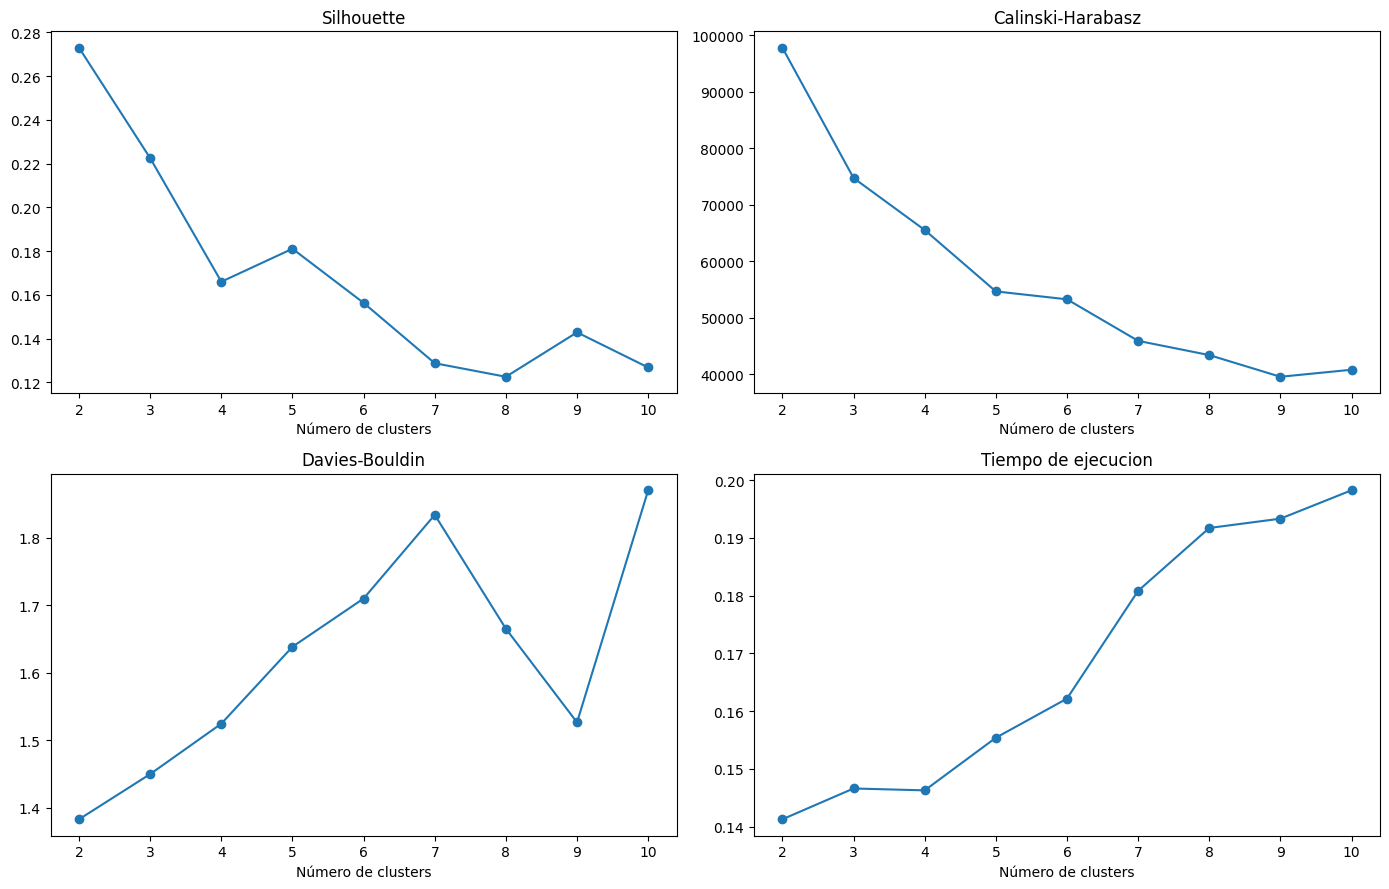

In [4]:
plot_clustering_metrics(
    resultados_clara,
    fourth_metric="tiempo_segundos",
    fourth_title="Tiempo de ejecución",
)

## Ajuste final y perfil de los clusters


In [ ]:
modelo, labels = fit_clustering_model(
    model_name="clara",
    k=2,
    X=X,
)

cluster_sizes, porcentajes, perfil_clusters, df_clusterizado = analyze_clusters(
    labels=labels,
    df_scaled=df_scaled_modelo,
    df_original=df_original,
    id_col="user_id",
)

print("Tamaño de los clusters:")
display(cluster_sizes)
print("Porcentaje de clientes:")
display(porcentajes)
print("Perfil medio de los clusters:")
display(perfil_clusters)

Tamaño de los clusters:


cluster
0    104515
1    101694
Name: count, dtype: int64

Porcentaje de clientes:


cluster
0    50.68
1    49.32
Name: proportion, dtype: float64

Perfil medio de los clusters:


,recency,frequency,avg_basket_size,std_basket_size,avg_days_between_orders,std_days_between_orders,unique_products,unique_aisles,unique_departments,reorder_ratio,product_variety_ratio
cluster,,,,,,,,,,,
0,12.284,24.191,12.337,5.265,10.928,7.624,99.826,38.953,13.359,0.538,0.462
1,21.972,6.751,7.500,3.240,15.999,11.385,28.268,16.304,8.226,0.324,0.676


- Cluster 0 - Clientes frecuentes y recurrentes (50,68%): presentan menor recencia, alta frecuencia y cestas grandes. Compran una variedad amplia de productos y categorías y tienen una elevada tasa de recompra.
- Cluster 1 - Clientes ocasionales y exploratorios (49,32%): llevan más tiempo sin comprar, realizan pocos pedidos y cestas pequeñas. Su recompra es baja y el ratio de variedad alto, lo que indica menor repetición relativa de productos.